In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# *Preproccessing*

In [255]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [256]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [257]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [258]:
df.duplicated().sum()

np.int64(0)

In [259]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
for value in  df["BloodPressure"] :
    if value == 0:
        remove = df[df["BloodPressure"] == 0].index
        df.drop(remove, inplace=True)

In [261]:
for value in  df["BMI"] :
    if value == 0:
        remove = df[df["BMI"] == 0].index
        df.drop(remove, inplace=True)

In [262]:
for value in df["SkinThickness"]:
    if value == 0:
        df.replace({"SkinThickness": 0}, np.random.uniform(1.55, 3), inplace=True)
for value in df["Glucose"]:
    if value == 0:
        df.replace({"Glucose": 0}, np.random.uniform(70, 125), inplace=True)

In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               729 non-null    int64  
 1   Glucose                   729 non-null    float64
 2   BloodPressure             729 non-null    int64  
 3   SkinThickness             729 non-null    float64
 4   Insulin                   729 non-null    int64  
 5   BMI                       729 non-null    float64
 6   DiabetesPedigreeFunction  729 non-null    float64
 7   Age                       729 non-null    int64  
 8   Outcome                   729 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 57.0 KB


In [264]:
for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Keep only the rows within bounds
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# *EDA*

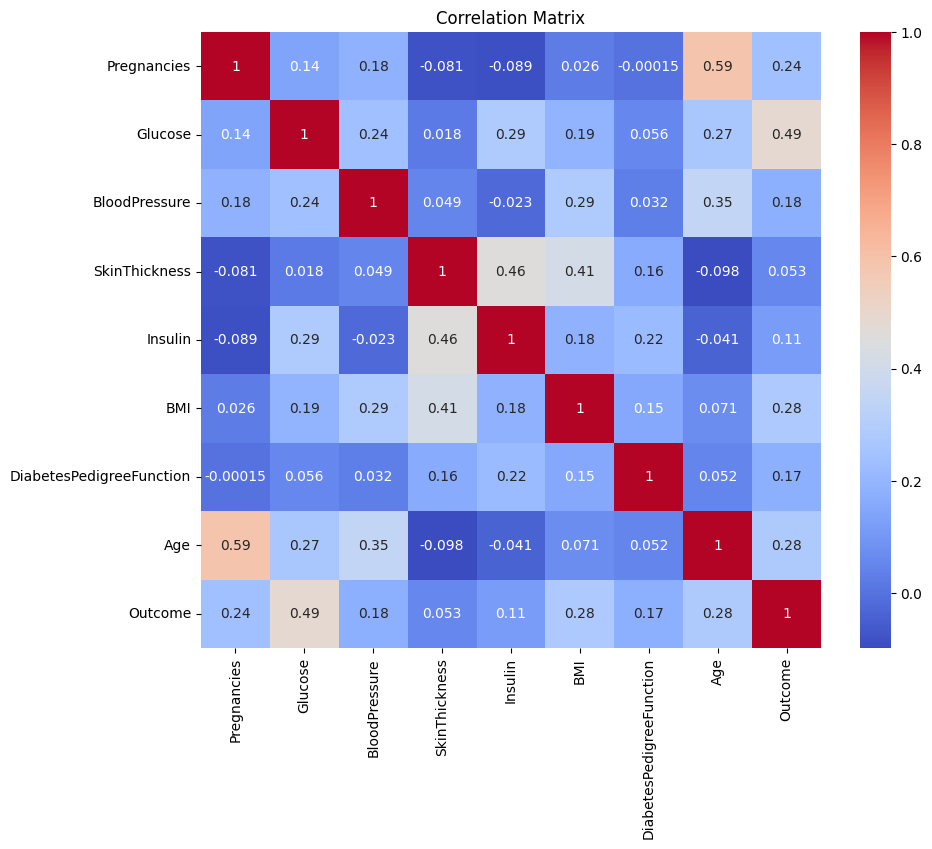

In [265]:
# 4. Correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

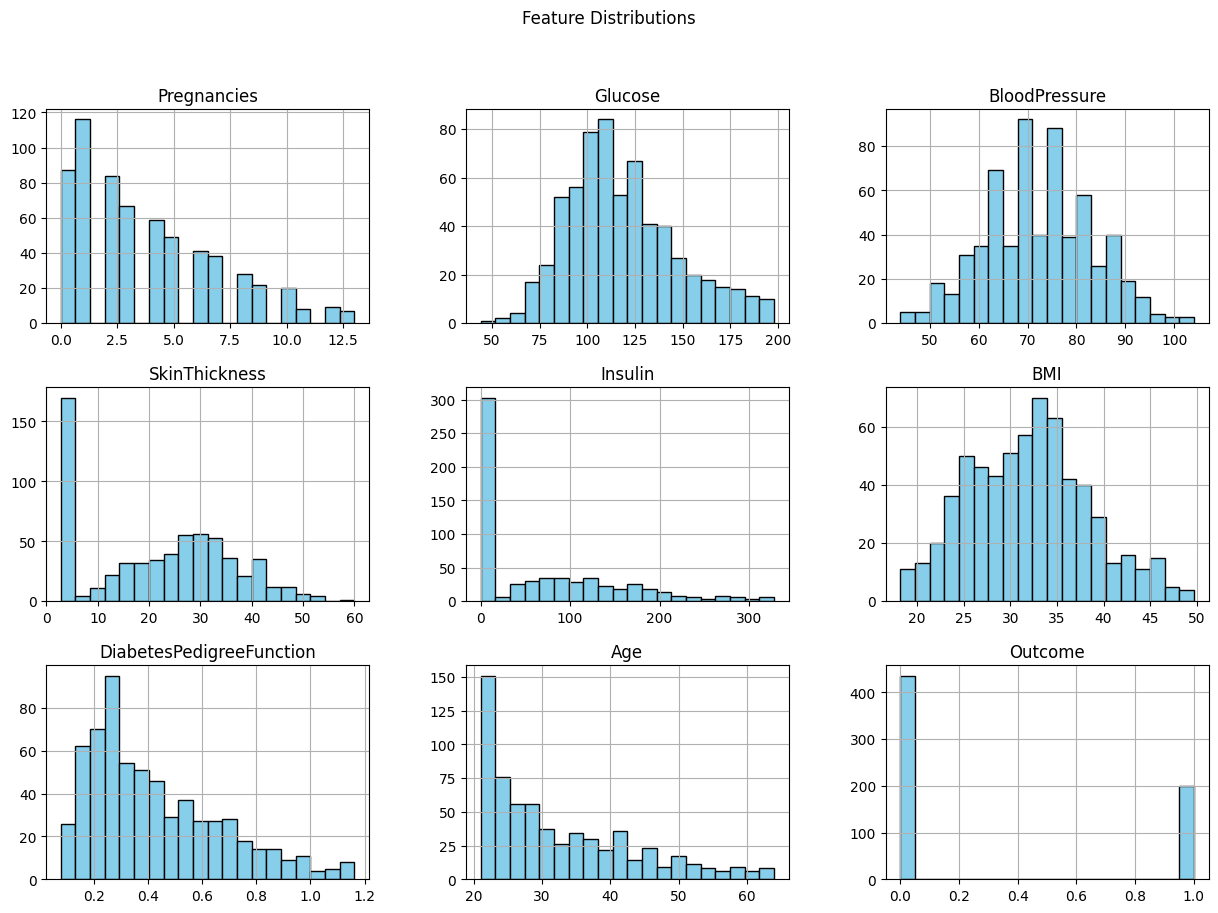

In [266]:
# 5. Distribution of each feature
df.hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Feature Distributions')
plt.show()

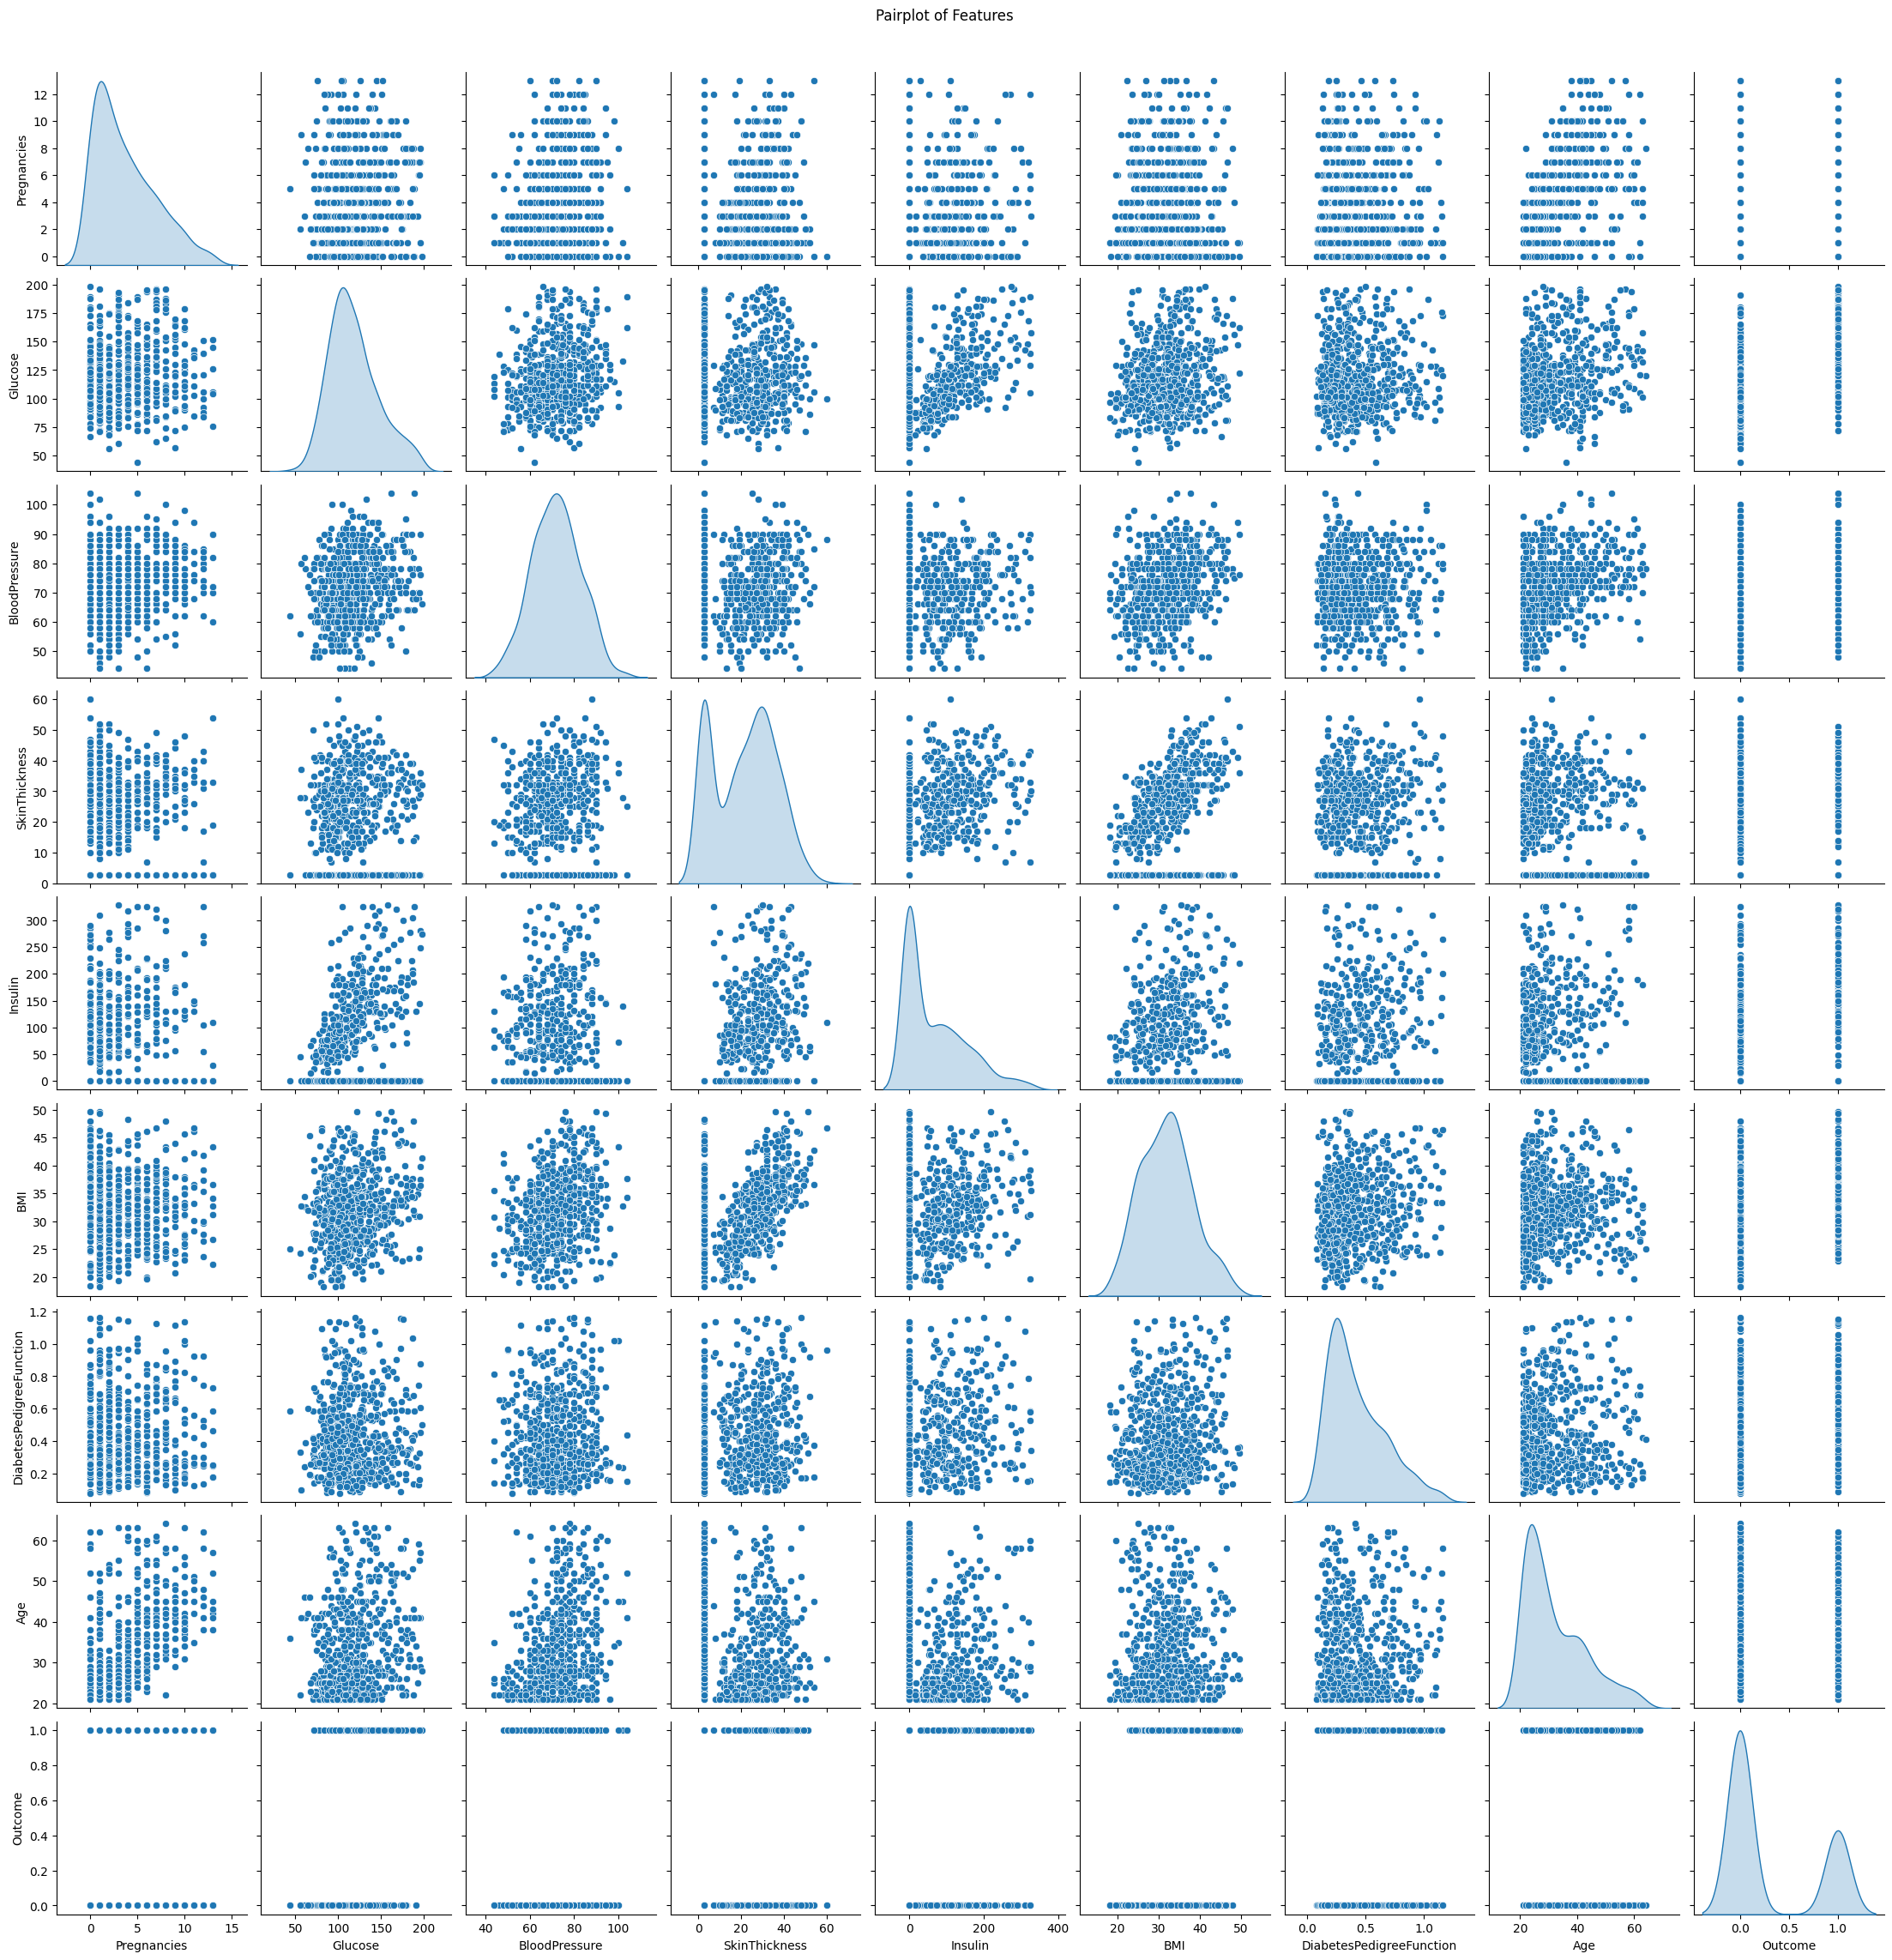

In [267]:
# 6. Pairplot to visualize relationships
sns.pairplot(df, diag_kind='kde')
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()

C:\Users\mostafa\AppData\Local\Temp\ipykernel_2516\3742758229.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='pastel')


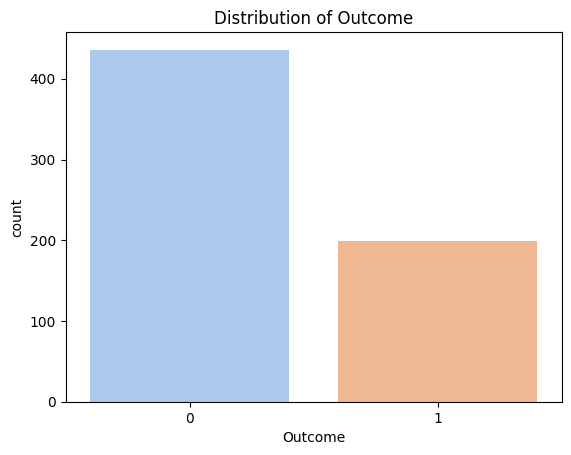

In [268]:
# 7. Target variable count plot (assuming 'Outcome' is the target)
if 'Outcome' in df.columns:
    sns.countplot(x='Outcome', data=df, palette='pastel')
    plt.title('Distribution of Outcome')
    plt.show()


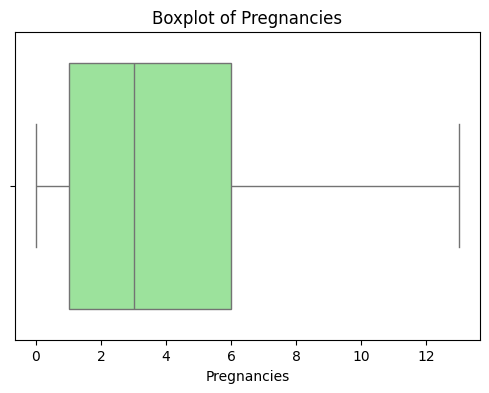

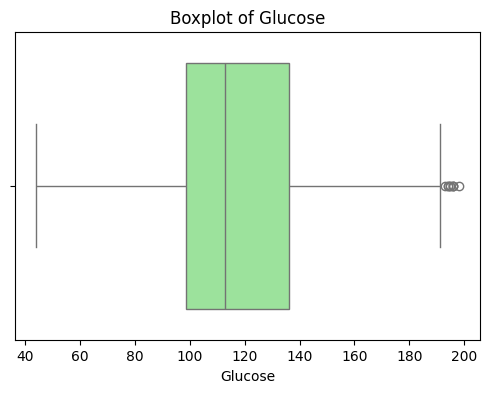

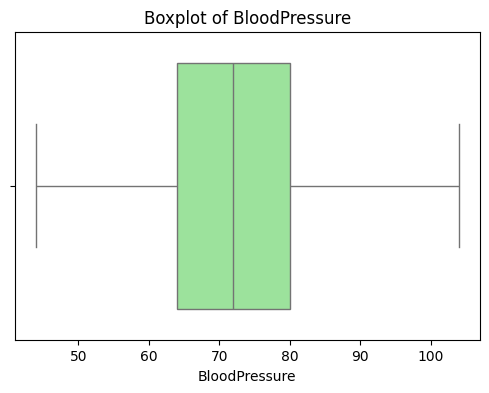

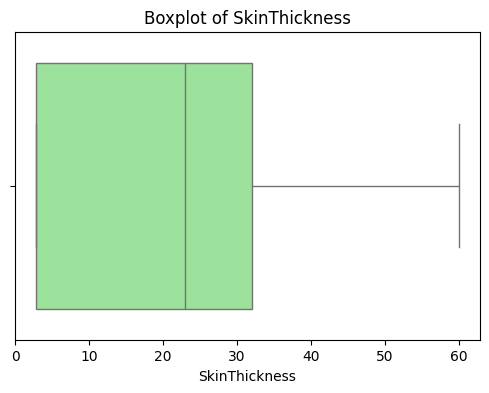

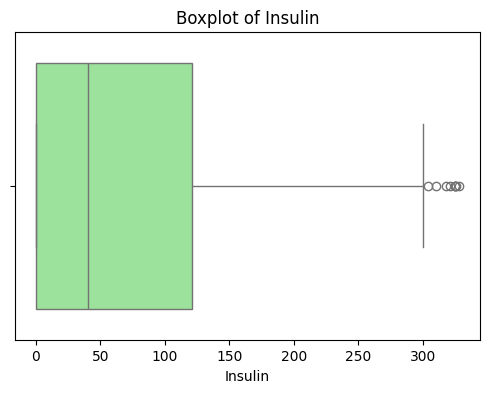

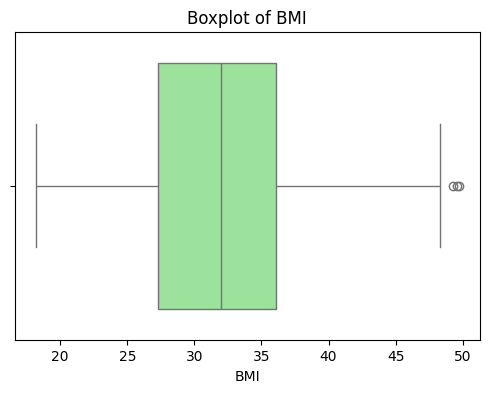

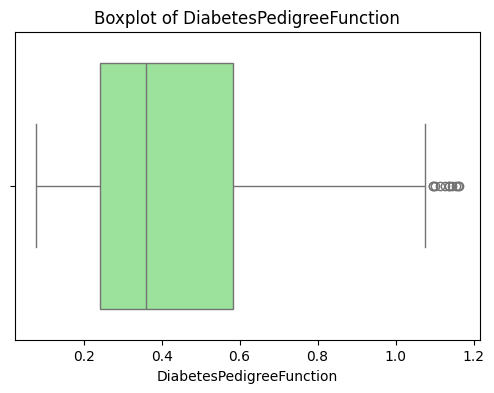

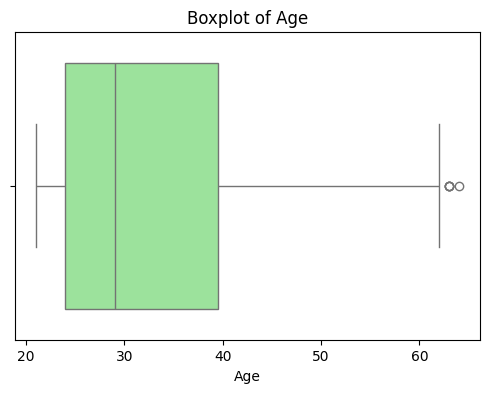

In [269]:
# 8. Boxplots to check for outliers
features = df.columns.drop('Outcome') if 'Outcome' in df.columns else df.columns
for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[feature], color='lightgreen')
    plt.title(f'Boxplot of {feature}')
    plt.show()

# *Modeling*

In [270]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [271]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [272]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [273]:
from sklearn.model_selection import cross_val_score

In [ ]:
model = RandomForestClassifier(max_depth=4, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=5)
print("Cross-validation accuracy:", scores.mean())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_train_pred= model.predict(X_train)

Cross-validation accuracy: 0.7769152196118488


In [276]:
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))



Accuracy: 0.8220720720720721

Confusion Matrix:
 [[292  13]
 [ 66  73]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.96      0.88       305
           1       0.85      0.53      0.65       139

    accuracy                           0.82       444
   macro avg       0.83      0.74      0.76       444
weighted avg       0.83      0.82      0.81       444



In [277]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7905759162303665

Confusion Matrix:
 [[124   7]
 [ 33  27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.95      0.86       131
           1       0.79      0.45      0.57        60

    accuracy                           0.79       191
   macro avg       0.79      0.70      0.72       191
weighted avg       0.79      0.79      0.77       191



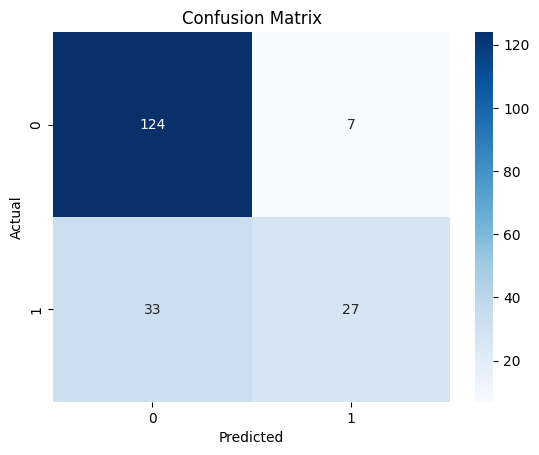

In [278]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [6]:
df_cleaned = pd.read_csv('diabetes_cleaned.csv')
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 635 entries, 0 to 634
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               635 non-null    int64  
 1   Glucose                   635 non-null    float64
 2   BloodPressure             635 non-null    int64  
 3   SkinThickness             635 non-null    float64
 4   Insulin                   635 non-null    int64  
 5   BMI                       635 non-null    float64
 6   DiabetesPedigreeFunction  635 non-null    float64
 7   Age                       635 non-null    int64  
 8   Outcome                   635 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 44.8 KB
